In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

iris = sns.load_dataset('iris')

print("IRIS DATASET OVERVIEW")
print(f"\nDataset Shape: {iris.shape}")
print(f"Rows: {iris.shape[0]}, Columns: {iris.shape[1]}")
print("\nFirst 5 rows:")
print(iris.head())
print("\nLast 5 rows:")
print(iris.tail())

IRIS DATASET OVERVIEW

Dataset Shape: (150, 5)
Rows: 150, Columns: 5

First 5 rows:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Last 5 rows:
     sepal_length  sepal_width  petal_length  petal_width    species
145           6.7          3.0           5.2          2.3  virginica
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica


In [14]:
print("1. FEATURES AND THEIR TYPES")

print("\nColumn Names and Data Types:")
for col in iris.columns:
    dtype = iris[col].dtype

    if pd.api.types.is_numeric_dtype(dtype):
        feature_type = "NUMERIC (Continuous)"
        col_min = iris[col].min()
        col_max = iris[col].max()
        print(f"{col:15s} | {str(dtype):10s} | {feature_type}")
        print(f"Range: [{col_min:.2f}, {col_max:.2f}]")
    else:
        feature_type = "NOMINAL (Categorical)"
        unique_vals = iris[col].unique()
        print(f"{col:15s} | {str(dtype):10s} | {feature_type}")
        print(f"Unique values: {list(unique_vals)}")

print("\nDetailed Info:")
print(iris.info())
print("\nStatistical Summary (Numeric Features):")
print(iris.describe())
print("\nClass Distribution:")
print(iris['species'].value_counts())

1. FEATURES AND THEIR TYPES

Column Names and Data Types:
sepal_length    | float64    | NUMERIC (Continuous)
Range: [4.30, 7.90]
sepal_width     | float64    | NUMERIC (Continuous)
Range: [2.00, 4.40]
petal_length    | float64    | NUMERIC (Continuous)
Range: [1.00, 6.90]
petal_width     | float64    | NUMERIC (Continuous)
Range: [0.10, 2.50]
species         | str        | NOMINAL (Categorical)
Unique values: ['setosa', 'versicolor', 'virginica']

Detailed Info:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB
None

Statistical Summary (Numeric Features):
       sepal_length  sepal_width  petal_leng

2. HISTOGRAMS - FEATURE DISTRIBUTIONS


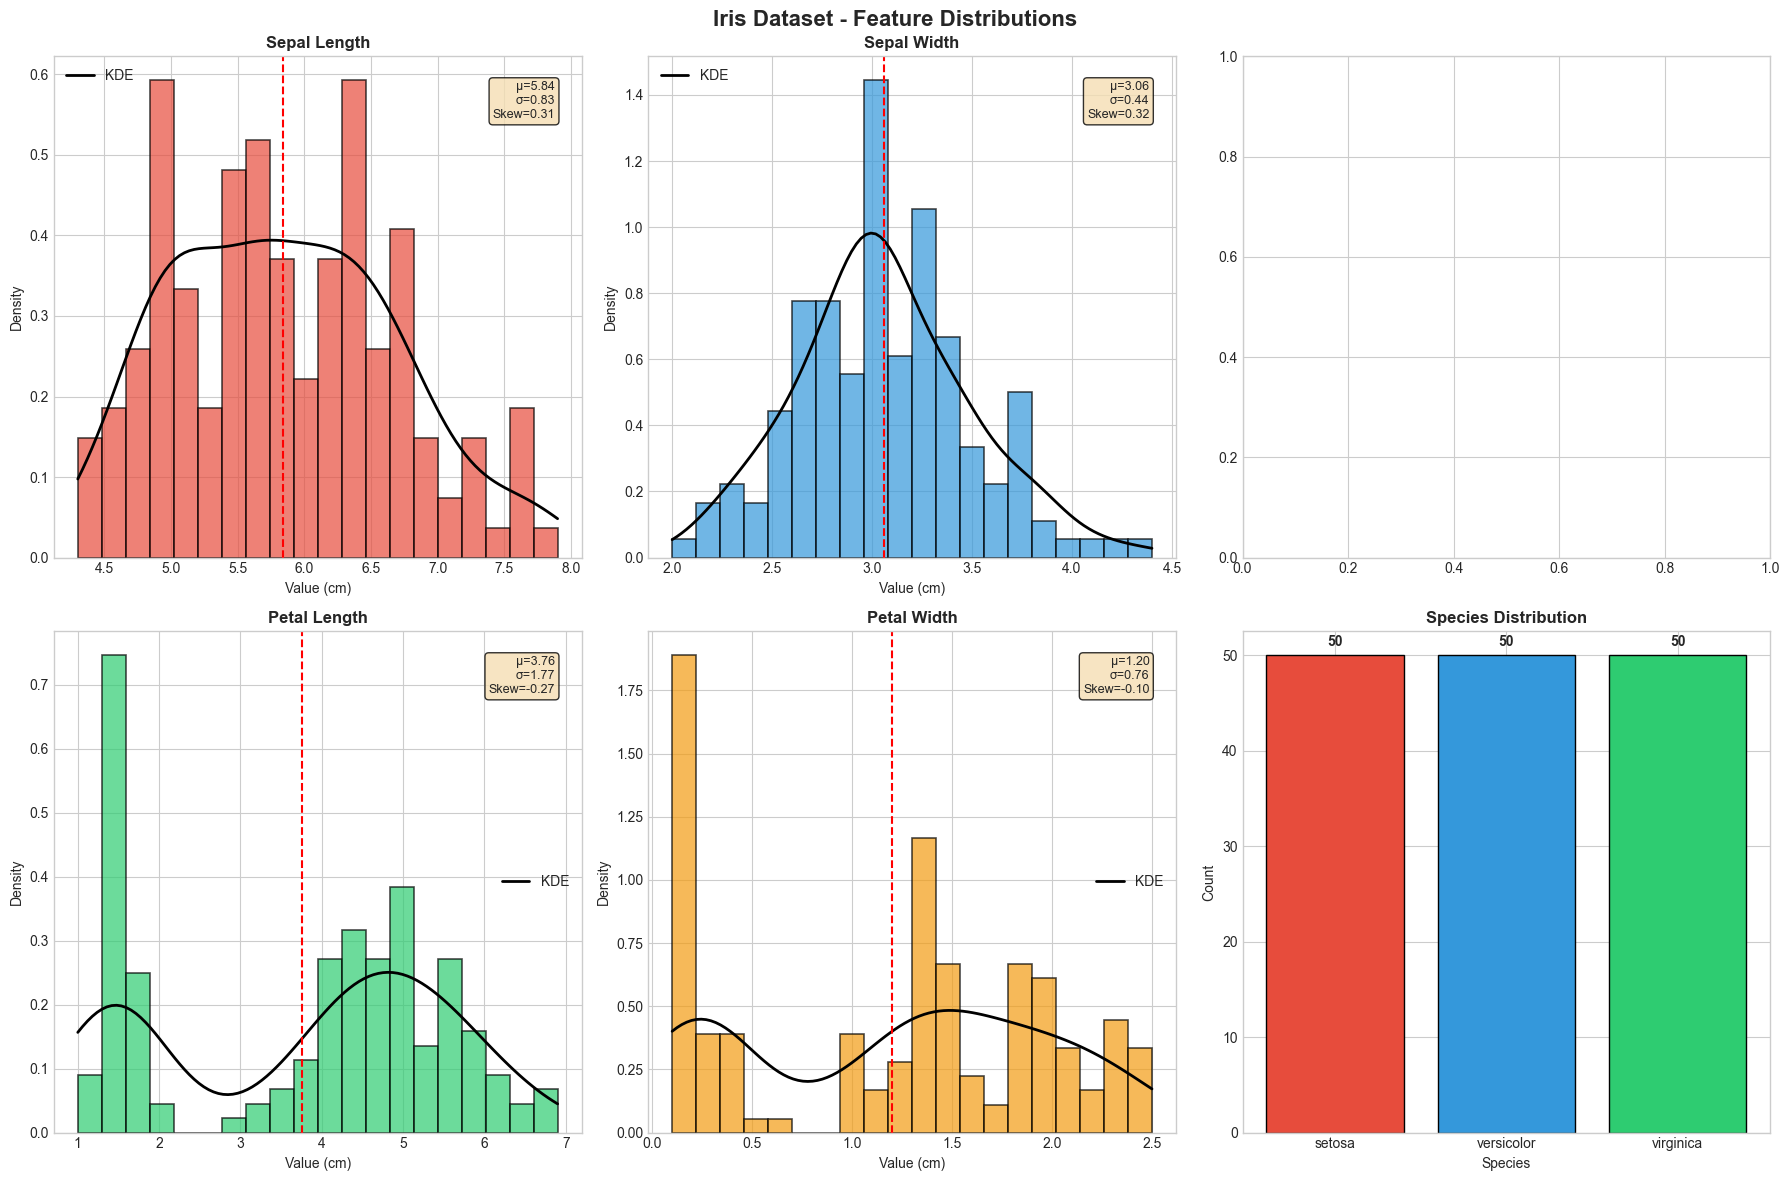

In [16]:
print("2. HISTOGRAMS - FEATURE DISTRIBUTIONS")

# Set up the plotting style
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Iris Dataset - Feature Distributions', fontsize=16, fontweight='bold')

numeric_features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

# Plot histograms for numeric features
for idx, (feature, color) in enumerate(zip(numeric_features, colors)):
    row = idx // 2
    col = idx % 2
    
    axes[row, col].hist(iris[feature], bins=20, color=color, alpha=0.7, 
                        edgecolor='black', linewidth=1.2, density=True)
    
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(iris[feature])
    x_range = np.linspace(iris[feature].min(), iris[feature].max(), 100)
    axes[row, col].plot(x_range, kde(x_range), 'k-', linewidth=2, label='KDE')
    
    axes[row, col].set_title(f'{feature.replace("_", " ").title()}', 
                             fontsize=12, fontweight='bold')
    axes[row, col].set_xlabel('Value (cm)', fontsize=10)
    axes[row, col].set_ylabel('Density', fontsize=10)
    axes[row, col].legend()
    
    mean_val = iris[feature].mean()
    std_val = iris[feature].std()
    axes[row, col].axvline(mean_val, color='red', linestyle='--', 
                          linewidth=1.5, label=f'Mean: {mean_val:.2f}')
    
    textstr = f'μ={mean_val:.2f}\nσ={std_val:.2f}\nSkew={iris[feature].skew():.2f}'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    axes[row, col].text(0.95, 0.95, textstr, transform=axes[row, col].transAxes,
                       fontsize=9, verticalalignment='top', horizontalalignment='right',
                       bbox=props)

species_counts = iris['species'].value_counts()
axes[1, 2].bar(species_counts.index, species_counts.values, 
               color=['#e74c3c', '#3498db', '#2ecc71'], edgecolor='black')
axes[1, 2].set_title('Species Distribution', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Species', fontsize=10)
axes[1, 2].set_ylabel('Count', fontsize=10)

for i, v in enumerate(species_counts.values):
    axes[1, 2].text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


3. BOX PLOTS - OUTLIER DETECTION


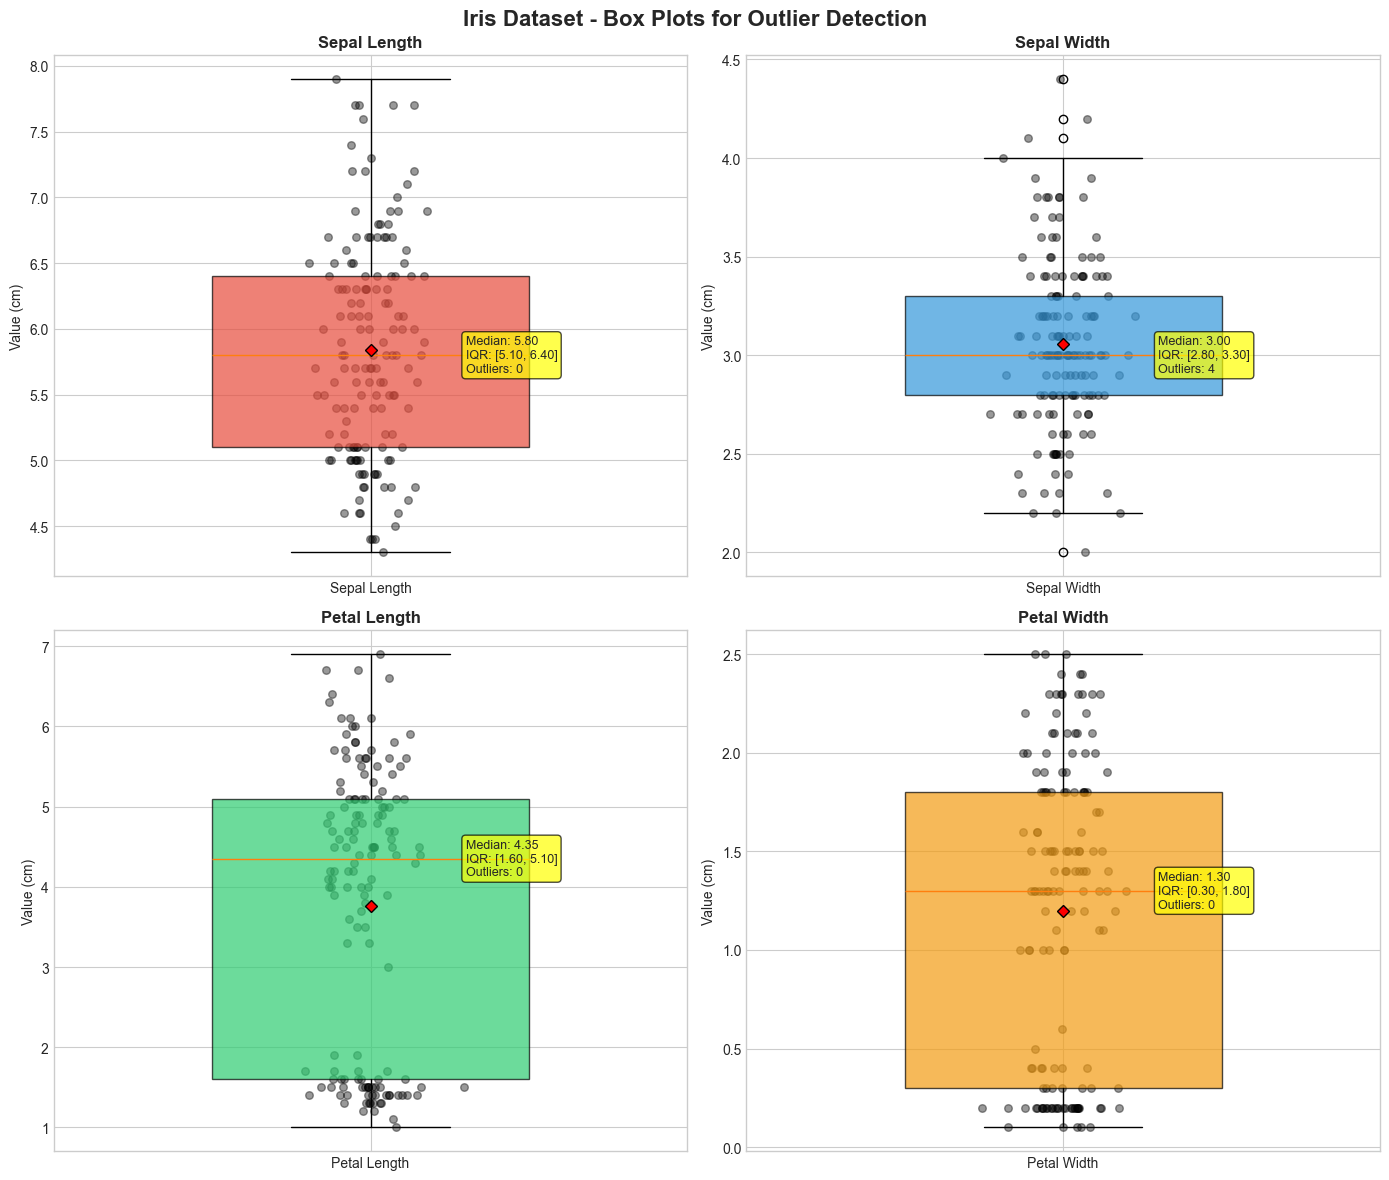

In [17]:
print("3. BOX PLOTS - OUTLIER DETECTION")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Iris Dataset - Box Plots for Outlier Detection', 
             fontsize=16, fontweight='bold')

for idx, feature in enumerate(numeric_features):
    row = idx // 2
    col = idx % 2
    
    # Create box plot
    box_plot = axes[row, col].boxplot(iris[feature], patch_artist=True,
                                       widths=0.5, showmeans=True,
                                       meanprops=dict(marker='D', 
                                                     markerfacecolor='red',
                                                     markeredgecolor='black'))
    
    box_plot['boxes'][0].set_facecolor(colors[idx])
    box_plot['boxes'][0].set_alpha(0.7)
    
    # Add individual points (jittered)
    y = iris[feature]
    x = np.random.normal(1, 0.04, size=len(y))
    axes[row, col].scatter(x, y, alpha=0.4, s=30, color='black')
    
    axes[row, col].set_title(f'{feature.replace("_", " ").title()}', 
                            fontsize=12, fontweight='bold')
    axes[row, col].set_ylabel('Value (cm)', fontsize=10)
    axes[row, col].set_xticklabels([feature.replace('_', ' ').title()])
    
    # Calculate and display statistics
    q1 = iris[feature].quantile(0.25)
    q3 = iris[feature].quantile(0.75)
    iqr = q3 - q1
    median = iris[feature].median()
    
    # Identify outliers
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = iris[(iris[feature] < lower_bound) | (iris[feature] > upper_bound)][feature]
    
    # Add statistics text
    stats_text = f'Median: {median:.2f}\nIQR: [{q1:.2f}, {q3:.2f}]\nOutliers: {len(outliers)}'
    axes[row, col].text(1.15, median, stats_text, fontsize=9, 
                       verticalalignment='center',
                       bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.show()

COMPARATIVE ANALYSIS BY SPECIES


C:\Users\acer\AppData\Local\Temp\ipykernel_9344\3418041327.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=iris, x='species', y=feature, ax=axes[row, col],
C:\Users\acer\AppData\Local\Temp\ipykernel_9344\3418041327.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=iris, x='species', y=feature, ax=axes[row, col],
C:\Users\acer\AppData\Local\Temp\ipykernel_9344\3418041327.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=iris, x='species', y=feature, ax=axes[row, col],
C:\Users\acer\AppData\Local\Temp\ipykernel_9344\3

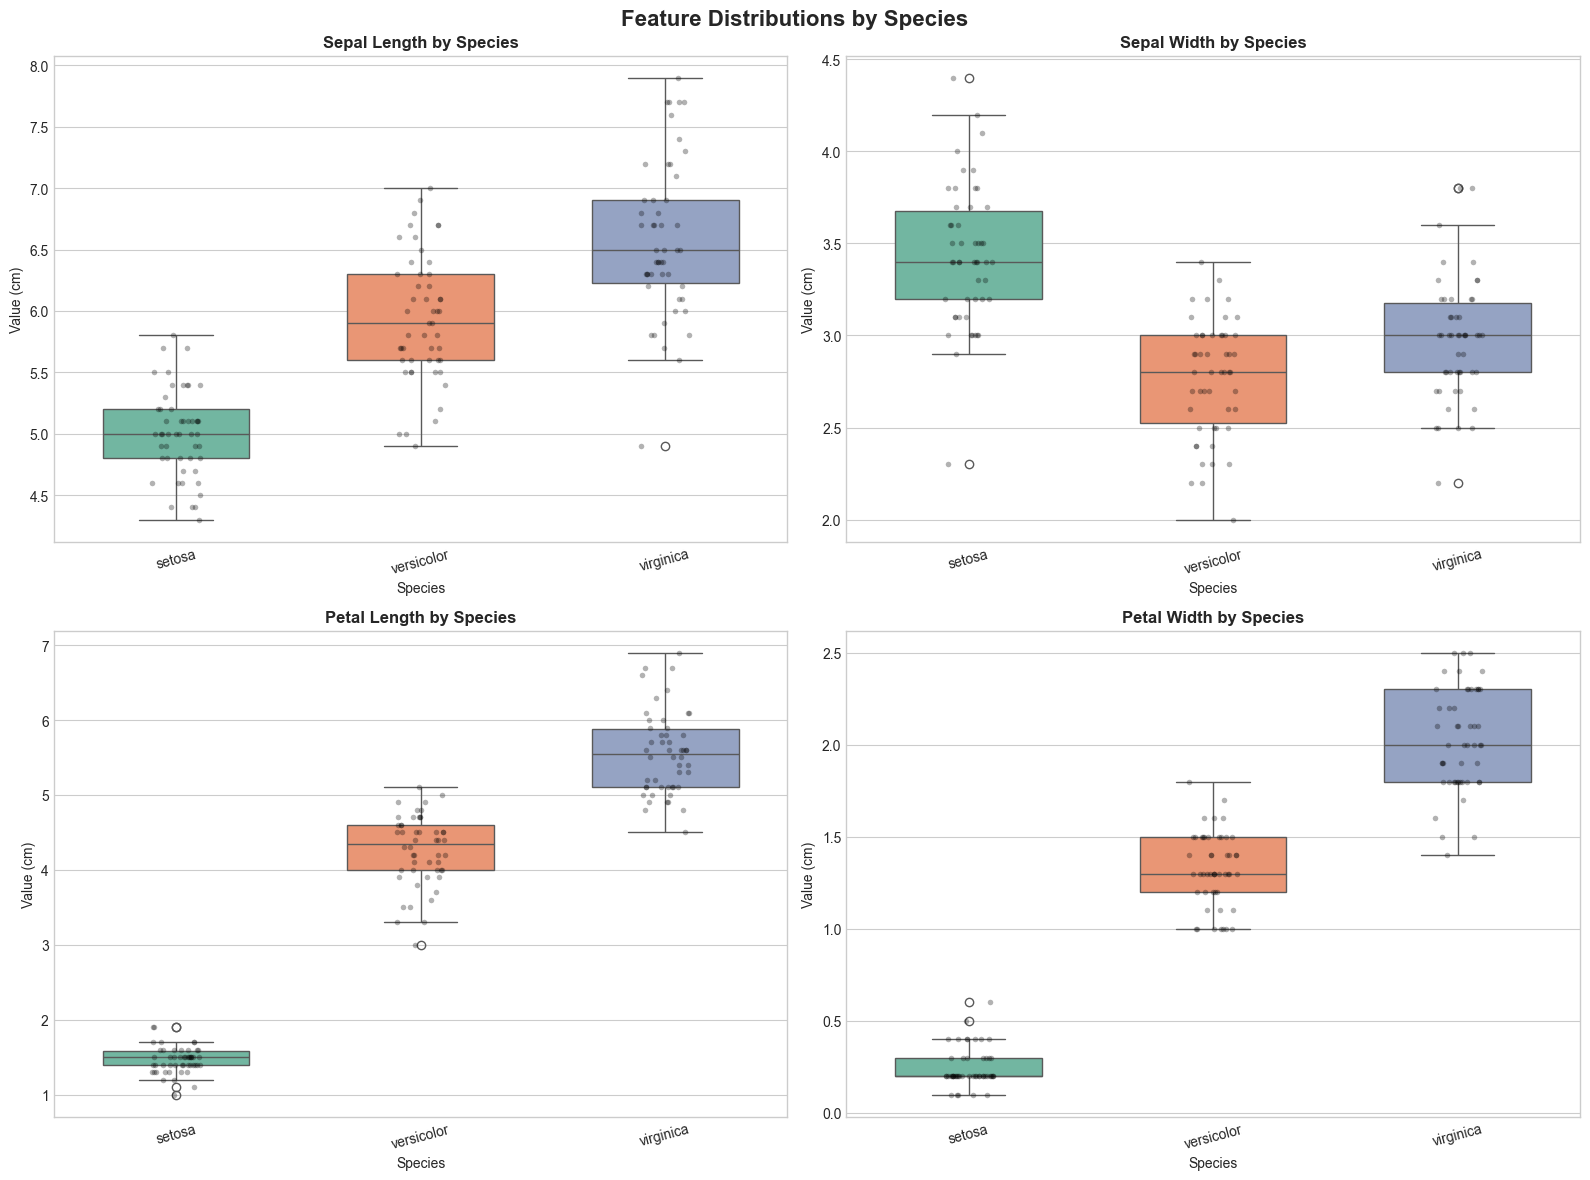

In [18]:
print("COMPARATIVE ANALYSIS BY SPECIES")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Feature Distributions by Species', fontsize=16, fontweight='bold')

for idx, feature in enumerate(numeric_features):
    row = idx // 2
    col = idx % 2
    
    # Create box plot grouped by species
    sns.boxplot(data=iris, x='species', y=feature, ax=axes[row, col], 
                palette='Set2', width=0.6)
    
    # Add strip plot for individual points
    sns.stripplot(data=iris, x='species', y=feature, ax=axes[row, col],
                  color='black', alpha=0.3, size=4, jitter=True)
    
    axes[row, col].set_title(f'{feature.replace("_", " ").title()} by Species', 
                            fontsize=12, fontweight='bold')
    axes[row, col].set_xlabel('Species', fontsize=10)
    axes[row, col].set_ylabel('Value (cm)', fontsize=10)
    
    axes[row, col].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [19]:
print("4. OUTLIER DETECTION ANALYSIS")

def detect_outliers_iqr(data, feature):
    """Detect outliers using IQR method"""
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[feature] < lower_bound) | (data[feature] > upper_bound)]
    return outliers, lower_bound, upper_bound, IQR

def detect_outliers_zscore(data, feature, threshold=3):
    """Detect outliers using Z-score method"""
    z_scores = np.abs(stats.zscore(data[feature]))
    outliers = data[z_scores > threshold]
    return outliers

print("\nMethod 1: Interquartile Range (IQR)")
print("-" * 50)

all_outliers = {}

for feature in numeric_features:
    outliers, lower, upper, iqr = detect_outliers_iqr(iris, feature)
    all_outliers[feature] = outliers
    
    print(f"\n{feature.replace('_', ' ').title()}:")
    print(f"  Q1: {iris[feature].quantile(0.25):.3f}")
    print(f"  Q3: {iris[feature].quantile(0.75):.3f}")
    print(f"  IQR: {iqr:.3f}")
    print(f"  Lower bound: {lower:.3f}")
    print(f"  Upper bound: {upper:.3f}")
    print(f"  Number of outliers: {len(outliers)}")
    
    if len(outliers) > 0:
        print(f"  Outlier values: {outliers[feature].values}")
        print(f"  Outlier indices: {outliers.index.tolist()}")

print("Method 2: Z-Score (|z| > 3)")

for feature in numeric_features:
    z_outliers = detect_outliers_zscore(iris, feature)
    print(f"\n{feature.replace('_', ' ').title()}: {len(z_outliers)} outliers")
    if len(z_outliers) > 0:
        print(f"  Indices: {z_outliers.index.tolist()}")

4. OUTLIER DETECTION ANALYSIS

Method 1: Interquartile Range (IQR)
--------------------------------------------------

Sepal Length:
  Q1: 5.100
  Q3: 6.400
  IQR: 1.300
  Lower bound: 3.150
  Upper bound: 8.350
  Number of outliers: 0

Sepal Width:
  Q1: 2.800
  Q3: 3.300
  IQR: 0.500
  Lower bound: 2.050
  Upper bound: 4.050
  Number of outliers: 4
  Outlier values: [4.4 4.1 4.2 2. ]
  Outlier indices: [15, 32, 33, 60]

Petal Length:
  Q1: 1.600
  Q3: 5.100
  IQR: 3.500
  Lower bound: -3.650
  Upper bound: 10.350
  Number of outliers: 0

Petal Width:
  Q1: 0.300
  Q3: 1.800
  IQR: 1.500
  Lower bound: -1.950
  Upper bound: 4.050
  Number of outliers: 0
Method 2: Z-Score (|z| > 3)

Sepal Length: 0 outliers

Sepal Width: 1 outliers
  Indices: [15]

Petal Length: 0 outliers

Petal Width: 0 outliers


CORRELATION ANALYSIS

Correlation Matrix:
              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000


C:\Users\acer\AppData\Local\Temp\ipykernel_9344\1347959523.py:17: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  pd.plotting.scatter_matrix(iris[numeric_features], alpha=0.6, figsize=(10, 10),


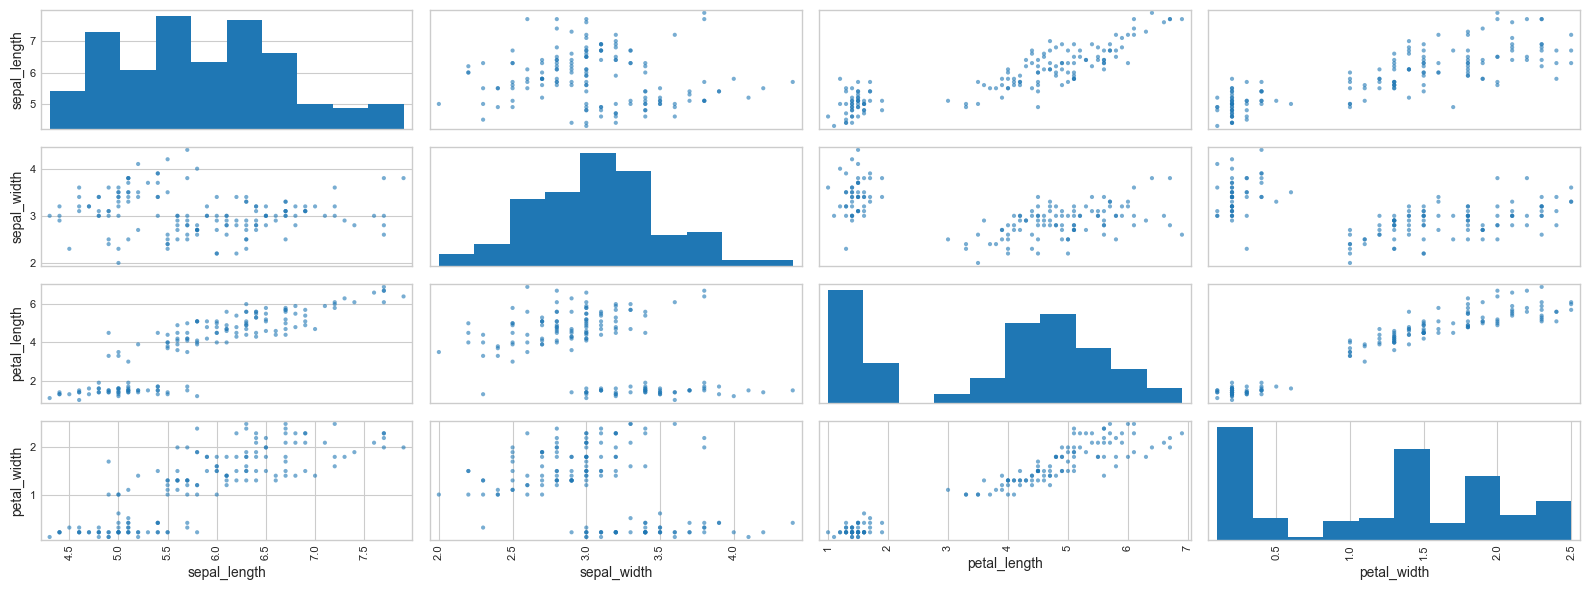

Correlation analysis saved as 'iris_correlation.png'


<Figure size 1200x1000 with 0 Axes>

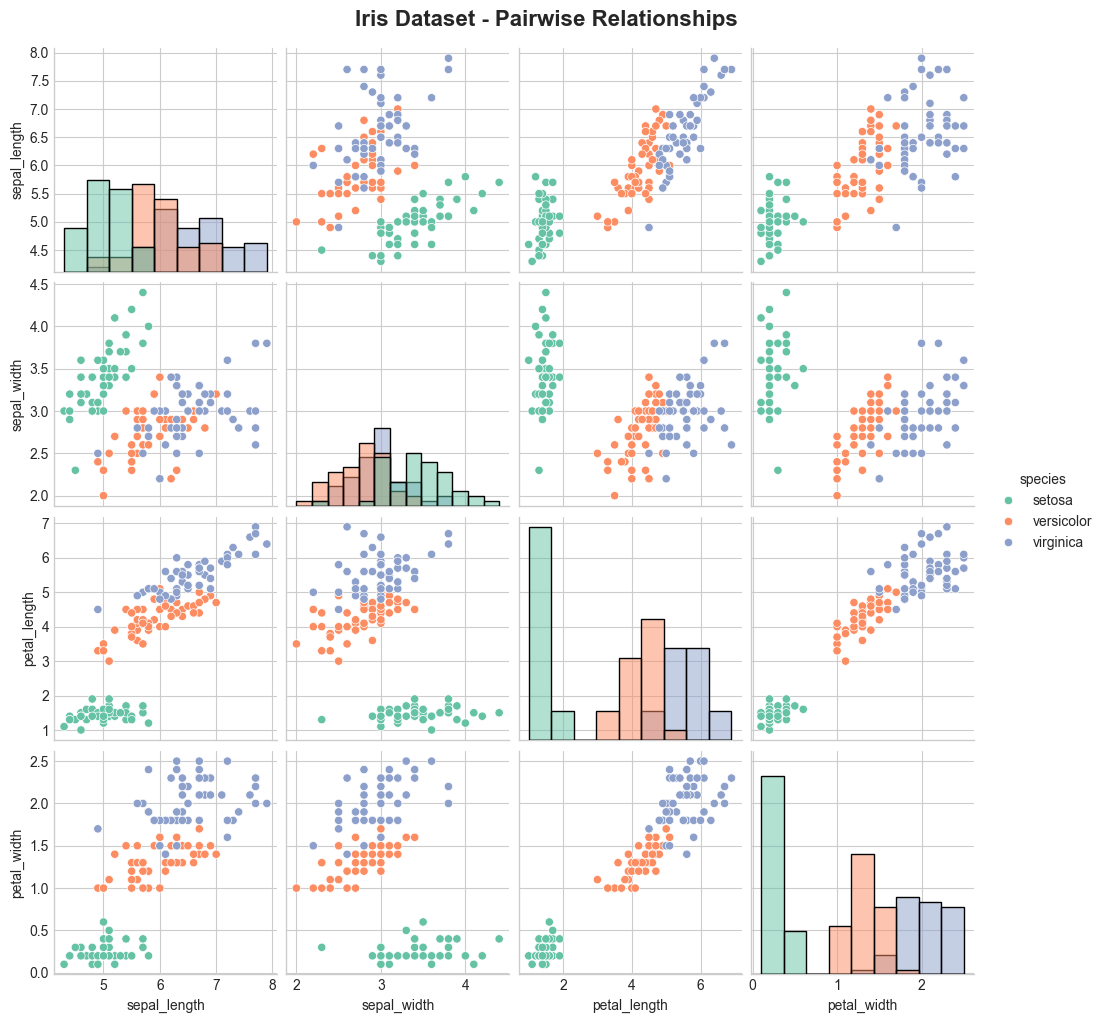

In [20]:
print("CORRELATION ANALYSIS")

# Correlation matrix
corr_matrix = iris[numeric_features].corr()
print("\nCorrelation Matrix:")
print(corr_matrix.round(3))

# Visualize correlation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=axes[0])
axes[0].set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')

from pandas.plotting import scatter_matrix
pd.plotting.scatter_matrix(iris[numeric_features], alpha=0.6, figsize=(10, 10), 
                          diagonal='hist', ax=axes[1])

axes[1].clear()
axes[1].scatter(iris['sepal_length'], iris['petal_length'], 
               c=iris['species'].astype('category').cat.codes, 
               cmap='viridis', alpha=0.7, s=60, edgecolors='black')
axes[1].set_xlabel('Sepal Length (cm)')
axes[1].set_ylabel('Petal Length (cm)')
axes[1].set_title('Sepal Length vs Petal Length', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('iris_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

print("Correlation analysis saved as 'iris_correlation.png'")

plt.figure(figsize=(12, 10))
pair_plot = sns.pairplot(iris, hue='species', palette='Set2', 
                         diag_kind='hist', height=2.5)
pair_plot.fig.suptitle('Iris Dataset - Pairwise Relationships', 
                       y=1.02, fontsize=16, fontweight='bold')
plt.show()

In [22]:
print("DISTRIBUTION ANALYSIS")

print("\nNormality Tests (Shapiro-Wilk):")

for feature in numeric_features:
    stat, p_value = stats.shapiro(iris[feature])
    is_normal = "Normal" if p_value > 0.05 else "Non-Normal"
    print(f"{feature:20s}: W={stat:.4f}, p={p_value:.4f} ({is_normal})")

print("\nSkewness and Kurtosis:")
for feature in numeric_features:
    skew = iris[feature].skew()
    kurt = iris[feature].kurtosis()
    print(f"{feature:20s}: Skewness={skew:7.3f}, Kurtosis={kurt:7.3f}")

DISTRIBUTION ANALYSIS

Normality Tests (Shapiro-Wilk):
sepal_length        : W=0.9761, p=0.0102 (Non-Normal)
sepal_width         : W=0.9849, p=0.1012 (Normal)
petal_length        : W=0.8763, p=0.0000 (Non-Normal)
petal_width         : W=0.9018, p=0.0000 (Non-Normal)

Skewness and Kurtosis:
sepal_length        : Skewness=  0.315, Kurtosis= -0.552
sepal_width         : Skewness=  0.319, Kurtosis=  0.228
petal_length        : Skewness= -0.275, Kurtosis= -1.402
petal_width         : Skewness= -0.103, Kurtosis= -1.341
